In [ ]:
import os
import random
import warnings
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Mammogram_Shape_Preprocess"

In [ ]:
import numpy as np

X_train = np.load(os.path.join(DATASET_PATH, "NEW_ROI_X_train.npy"))
Y_train = np.load(os.path.join(DATASET_PATH, "NEW_ROI_Y_train.npy"))

print("Images:", X_train.shape, X_train.dtype)
print("Masks :", Y_train.shape, Y_train.dtype)

print("Image min/max:", X_train.min(), X_train.max())
print("Mask unique values:", np.unique(Y_train)[:20])

Images: (1004, 128, 128, 1) float32
Masks : (1004, 128, 128, 1) uint8
Image min/max: 0.003921569 1.0
Mask unique values: [0 1]


In [ ]:
import os

YOLO_PATH = os.path.join(DATASET_PATH, "YOLO_dataset")

folders = [
    "images/train",
    "images/val",
    "images/test",
    "labels/train",
    "labels/val",
    "labels/test",
]

for folder in folders:
    os.makedirs(os.path.join(YOLO_PATH, folder), exist_ok=True)

print("Folder structure created successfully!")

Folder structure created successfully!


In [ ]:
import numpy as np

X_train = np.load(os.path.join(DATASET_PATH, "NEW_ROI_X_train.npy"))
Y_train = np.load(os.path.join(DATASET_PATH, "NEW_ROI_Y_train.npy"))

X_val = np.load(os.path.join(DATASET_PATH, "NEW_ROI_X_val.npy"))
Y_val = np.load(os.path.join(DATASET_PATH, "NEW_ROI_Y_val.npy"))

X_test = np.load(os.path.join(DATASET_PATH, "NEW_ROI_X_test.npy"))
Y_test = np.load(os.path.join(DATASET_PATH, "NEW_ROI_Y_test.npy"))

In [ ]:
import cv2
import os

def save_yolo_dataset(images, masks, split):

    image_dir = os.path.join(YOLO_PATH, "images", split)
    label_dir = os.path.join(YOLO_PATH, "labels", split)

    for idx in range(len(images)):

        # ---------- Save image ----------
        img = (images[idx].squeeze() * 255).astype("uint8")

        image_name = f"{idx:05d}.png"

        cv2.imwrite(
            os.path.join(image_dir, image_name),
            img
        )

        # ---------- Save label ----------
        mask = masks[idx].squeeze().astype("uint8")

        contours, _ = cv2.findContours(
            mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_NONE
        )

        h, w = mask.shape

        txt_path = os.path.join(
            label_dir,
            image_name.replace(".png", ".txt")
        )

        with open(txt_path, "w") as f:

            for contour in contours:

                if len(contour) < 3:
                    continue

                contour = contour.squeeze()

                if contour.ndim != 2:
                    continue

                polygon = []

                for x, y in contour:
                    polygon.append(f"{x/w:.6f}")
                    polygon.append(f"{y/h:.6f}")

                line = "0 " + " ".join(polygon)

                f.write(line + "\n")

In [ ]:
save_yolo_dataset(X_train, Y_train, "train")
save_yolo_dataset(X_val, Y_val, "val")
save_yolo_dataset(X_test, Y_test, "test")

print("YOLO dataset created successfully!")

YOLO dataset created successfully!


In [ ]:
yaml_text = f"""
path: {YOLO_PATH}

train: images/train
val: images/val
test: images/test

names:
  0: lesion
"""

with open(os.path.join(YOLO_PATH, "dataset.yaml"), "w") as f:
    f.write(yaml_text)

print("dataset.yaml created!")

dataset.yaml created!


In [ ]:
import os

label_dir = os.path.join(YOLO_PATH, "labels", "train")

for file in sorted(os.listdir(label_dir))[:5]:
    print(file)
    with open(os.path.join(label_dir, file), "r") as f:
        print(f.read())
        print("-" * 60)

00000.txt
0 0.515625 0.382812 0.507812 0.390625 0.500000 0.390625 0.507812 0.398438 0.500000 0.406250 0.492188 0.406250 0.484375 0.406250 0.476562 0.414062 0.468750 0.406250 0.460938 0.406250 0.453125 0.406250 0.445312 0.406250 0.437500 0.414062 0.429688 0.406250 0.421875 0.406250 0.414062 0.406250 0.414062 0.414062 0.406250 0.421875 0.398438 0.421875 0.398438 0.429688 0.398438 0.437500 0.398438 0.445312 0.390625 0.453125 0.382812 0.453125 0.375000 0.460938 0.382812 0.468750 0.382812 0.476562 0.390625 0.484375 0.390625 0.492188 0.398438 0.500000 0.390625 0.507812 0.390625 0.515625 0.398438 0.523438 0.390625 0.531250 0.398438 0.531250 0.406250 0.531250 0.414062 0.539062 0.414062 0.546875 0.414062 0.554688 0.421875 0.562500 0.421875 0.570312 0.429688 0.578125 0.437500 0.585938 0.437500 0.593750 0.445312 0.593750 0.453125 0.601562 0.460938 0.593750 0.468750 0.585938 0.476562 0.593750 0.484375 0.585938 0.492188 0.593750 0.500000 0.593750 0.507812 0.593750 0.515625 0.601562 0.523438 0.60937

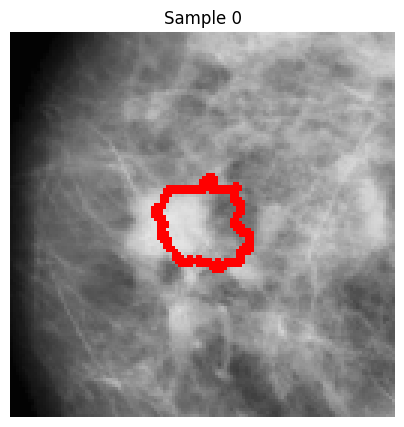

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

idx = 0   # change to 1,2,3,...

img_path = os.path.join(YOLO_PATH, "images", "train", f"{idx:05d}.png")
label_path = os.path.join(YOLO_PATH, "labels", "train", f"{idx:05d}.txt")

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

h, w = img.shape

with open(label_path) as f:
    for line in f:
        vals = line.strip().split()
        pts = np.array(vals[1:], dtype=np.float32).reshape(-1, 2)
        pts[:, 0] *= w
        pts[:, 1] *= h
        pts = pts.astype(np.int32)

        cv2.polylines(overlay, [pts], True, (255, 0, 0), 2)

plt.figure(figsize=(5,5))
plt.imshow(overlay)
plt.title(f"Sample {idx}")
plt.axis("off")
plt.show()